https://www.kaggle.com/datasets/ashfakyeafi/spam-email-classification

SPAM EMAIl DETECTIOn

Bộ dữ liệu Spam Email Classification trên Kaggle của tác giả Ashfak Yeafi là một tập dữ liệu chuẩn rất phổ biến dùng cho các bài toán Xử lý ngôn ngữ tự nhiên (NLP) và Phân loại văn bản (Text Classification), cụ thể là bài toán Phát hiện thư rác (Spam Detection).   Dưới đây là phần giải thích chi tiết về cấu trúc, đặc điểm và cách tiếp cận để xử lý tập dữ liệu này:

1. Cấu trúc của DatasetBộ dữ liệu thường gồm các cột cơ bản sau:   text (hoặc Message): Chứa nội dung văn bản thô của email hoặc tin nhắn. Đây là nơi lưu trữ các câu chữ thực tế (ví dụ: các thông báo trúng thưởng, link lạ, hoặc các đoạn hội thoại công việc bình thường).   label (hoặc nhãn phân loại):   ham: Thư hợp lệ, tin nhắn bình thường từ bạn bè, công việc hoặc hệ thống (chiếm đa số, khoảng 85% - 87%).   spam: Thư rác, tin nhắn quảng cáo rác, lừa đảo, thông báo trúng thưởng giả mạo (chiếm phần ít hơn, khoảng 13% - 15%).   

2. Đặc điểm nổi bật và Thách thức
Bài toán Mất cân bằng dữ liệu (Class Imbalance): Giống như bài toán phát hiện gian lận (Fraud Detection) bạn vừa làm ở trên, số lượng tin nhắn rác (spam) trong tập này thấp hơn rất nhiều so với tin nhắn thường (ham). Do đó, nếu chỉ nhìn vào độ chính xác tổng thể (Accuracy), mô hình có thể đạt 95% nhưng lại bỏ sót phần lớn tin nhắn spam.

Đặc trưng dạng văn bản (Unstructured Data): Máy tính không hiểu trực tiếp được chữ cái hay từ vựng. Bạn bắt buộc phải chuyển đổi văn bản thô thành các dạng ma trận số học (Vectorization) thì các thuật toán như XGBoost, Random Forest, hay Logistic Regression mới đọc được.


3. Quy trình chuẩn để xử lý và huấn luyện trên Dataset này
Nếu bạn muốn xây dựng một mô hình phân loại cho tập dữ liệu này, luồng xử lý chuẩn (Pipeline) sẽ gồm các bước:

Tiền xử lý văn bản (Text Preprocessing):

Chuyển toàn bộ văn bản về chữ thường (lowercase).

Loại bỏ các dấu câu, ký tự đặc biệt, chữ số thừa hoặc các thẻ HTML (nếu có).

Loại bỏ các từ dừng (Stop words - những từ xuất hiện nhiều nhưng ít mang ý nghĩa phân loại như the, is, at, on...).

Khử từ gốc (Stemming / Lemmatization) để đưa các từ về dạng nguyên bản (ví dụ: running, runs $\rightarrow$ run).

Trích xuất đặc trưng (Feature Extraction):Sử dụng TF-IDF (Term Frequency-Inverse Document Frequency) hoặc Bag of Words (BoW) để biến đổi các câu chữ thành các cột số đại diện cho tần suất xuất hiện của từ khóa. Các từ khóa mang tính chất "nhạy cảm" hay gặp ở spam (như free, win, cash, prize, urgent, click...) sẽ có trọng số cao.   

Huấn luyện mô hình:Mô hình cơ bản (Baseline): Naive Bayes (MultinomialNB) hoặc Logistic Regression (thường rất hiệu quả và chạy cực nhanh với dữ liệu văn bản đi kèm TF-IDF).   Mô hình nâng cao: Random Forest, XGBoost, hoặc CatBoost (sau khi đã biến đổi văn bản thành ma trận đặc trưng số).

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [99]:
plt.style.use("ggplot")

để thay đổi giao diện và phong cách hiển thị của các biểu đồ sang một giao diện chuẩn mực, đẹp mắt hơn.

In [100]:
df = pd.read_csv("email.csv")

In [101]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [102]:
df.shape

(5573, 2)

In [103]:
df.tail(2)

,Category,Message
5571,ham,Rofl. Its true to its name
5572,"{""mode"":""full""",isActive:false}


In [104]:
df["Category"].value_counts()

Category
ham               4825
spam               747
{"mode":"full"       1
Name: count, dtype: int64

In [105]:
df = df.iloc[:-1]

cắt bỏ (hoặc xóa) dòng cuối cùng

In [106]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [107]:
df.shape

(5572, 2)

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [109]:
df.isnull()

,Category,Message
0,False,False
1,False,False
2,False,False
3,False,False
4,False,False
...,...,...
5567,False,False
5568,False,False
5569,False,False
5570,False,False


In [110]:
df.isnull().sum()

Category    0
Message     0
dtype: int64

In [111]:
df.isnull().sum().sum()

0

In [112]:
df.duplicated().sum()

415

In [113]:
df.duplicated().sum() / df.shape[0]

0.07447954055994258

tính tỷ lệ phần trăm các dòng bị lặp lại (trùng hoàn toàn) trong toàn bộ DataFrame.

In [114]:
df.drop_duplicates(inplace=True)

xóa bỏ toàn bộ các dòng dữ liệu bị trùng lặp hoàn toàn (duplicate rows) có trong DataFrame.

inplace=True: Tham số quan trọng giúp thực hiện thao tác xóa trực tiếp ngay trên DataFrame gốc mà không cần phải gán lại qua biến mới (tương đương với việc viết df = df.drop_duplicates()).

In [115]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [116]:
df["Category"].value_counts()

Category
ham     4516
spam     641
Name: count, dtype: int64

In [117]:
df["Category"].value_counts(normalize=True) *100

Category
ham     87.570293
spam    12.429707
Name: proportion, dtype: float64

dùng để tính tỷ lệ phần trăm phân bố của từng nhãn/lớp (Category) trong tập dữ liệu.

Tham số normalize=True -> ra %: đổi kết quả đếm thành tần suất tương ứng (xác suất/tỷ lệ từ 0 đến 1) thay vì số lượng đếm thô.

Text(0.5, 1.0, 'Email Category Distribute')

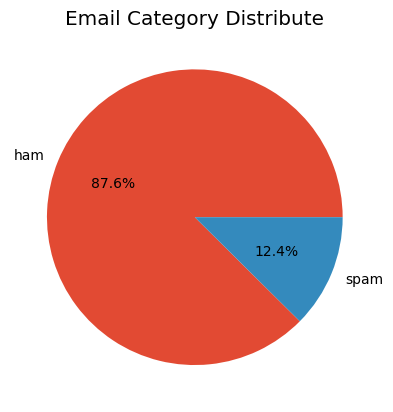

In [118]:
df["Category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Email Category Distribute")

In [119]:
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [120]:
df["Message_Length"] = df["Message"].apply(len)

để tạo một cột mới tên là "Message_Length" trong DataFrame, lưu độ dài (tổng số ký tự) của từng tin nhắn/email.

apply(len): Phương thức .apply() dùng để áp dụng một hàm số lên từng phần tử (từng dòng) trong cột. Ở đây hàm được áp dụng là len() (hàm đếm số ký tự chuẩn của Python). Nó sẽ đếm xem câu trong từng dòng có bao nhiêu ký tự (bao gồm cả chữ cái, khoảng trắng và dấu câu).

In [121]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [122]:
df["Message"][1]

'Ok lar... Joking wif u oni...'

In [123]:
df["Message_Length"].describe()

count    5157.000000
mean       79.103936
std        58.382922
min         2.000000
25%        36.000000
50%        61.000000
75%       118.000000
max       910.000000
Name: Message_Length, dtype: float64

In [124]:
df["Message_Length"].median()

61.0

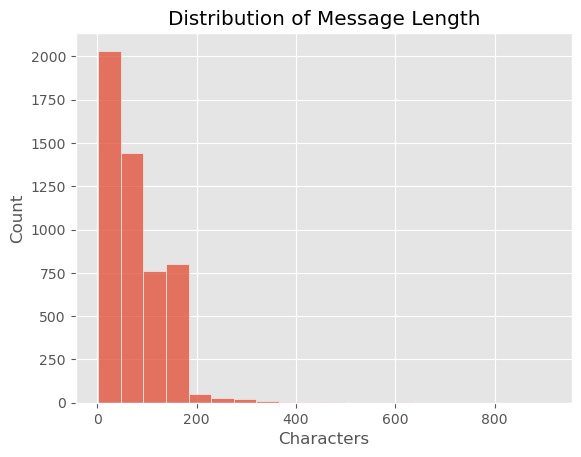

In [125]:
sns.histplot(df["Message_Length"], bins=20)

plt.title("Distribution of Message Length")

plt.xlabel("Characters")

plt.show()

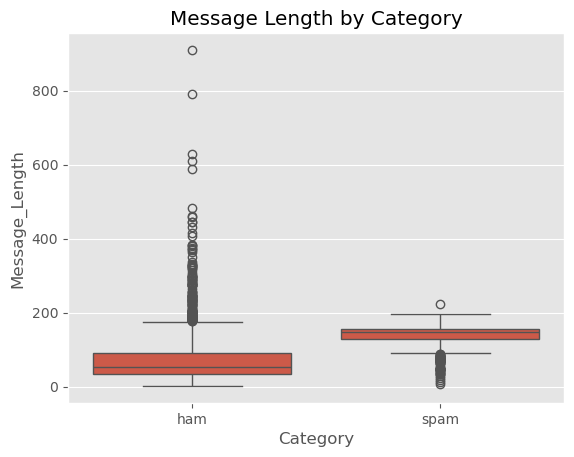

In [126]:
sns.boxplot(
    data=df,
    x = "Category",
    y = "Message_Length"
)

plt.title("Message Length by Category")

plt.show()

Seaborn (sns) để vẽ biểu đồ hộp (Boxplot) nhằm so sánh độ dài tin nhắn (Message_Length) giữa các nhóm nhãn khác nhau (Category - ví dụ: ham và spam).

In [127]:
df.groupby("Category")["Message_Length"].mean()

Category
ham      70.869353
spam    137.118565
Name: Message_Length, dtype: float64

dùng để tính độ dài trung bình (số lượng ký tự trung bình) của tin nhắn cho từng nhóm nhãn riêng biệt (ham và spam).

Text(0.5, 1.0, 'Average Message Length')

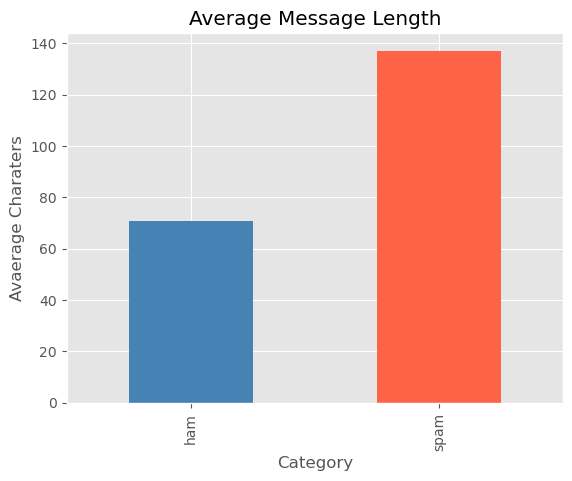

In [128]:
df.groupby("Category")["Message_Length"].mean().plot(
    kind="bar",
    color = ["steelblue", "tomato"]
)

plt.ylabel("Avaerage Charaters")
plt.title("Average Message Length")

In [129]:
df.head()

,Category,Message,Message_Length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [130]:
df["Word_Count"] = df["Message"].apply(lambda x: len(x.split()))

tạo một cột mới tên là "Word_Count" trong bảng dữ liệu, lưu tổng số từ (số lượng từ) có trong mỗi tin nhắn.

In [131]:
df.head()

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13


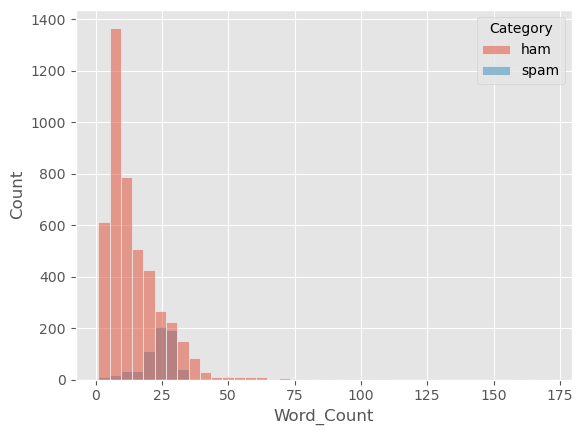

In [132]:
sns.histplot(
    data=df,
    x="Word_Count",
    bins=40,
    hue="Category"
)
plt.show()

In [133]:
df.groupby("Category")["Word_Count"].mean()

Category
ham     14.239814
spam    23.659906
Name: Word_Count, dtype: float64

In [134]:
df.nsmallest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1925,ham,Ok,2,1
3376,ham,:),2,1
261,ham,Yup,3,1
1612,ham,645,3,1
2182,ham,Ok.,3,1
287,ham,Ok..,4,1
2602,ham,Okie,4,1
5173,ham,U 2.,4,2
1273,ham,Ok...,5,1
4293,ham,G.W.R,5,1


lọc và hiển thị 10 dòng có giá trị nhỏ nhất trong cột "Message_Length" (tức là 10 tin nhắn có độ dài ngắn nhất).

In [135]:
df.nlargest(10, "Message_Length")

,Category,Message,Message_Length,Word_Count
1085,ham,For me the love should start with attraction.i...,910,171
1863,ham,The last thing i ever wanted to do was hurt yo...,790,162
2434,ham,Indians r poor but India is not a poor country...,629,109
1579,ham,How to Make a girl Happy? It's not at all diff...,611,103
2158,ham,Sad story of a Man - Last week was my b'day. M...,588,125
2380,ham,"Good evening Sir, hope you are having a nice d...",482,98
3017,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,66
1513,ham,"Hey sweet, I was wondering when you had a mome...",458,95
2370,ham,A Boy loved a gal. He propsd bt she didnt mind...,446,96
2408,ham,Solve d Case : A Man Was Found Murdered On &l...,444,71


để lọc và hiển thị 10 dòng có giá trị lớn nhất trong cột "Message_Length" (tức là 10 tin nhắn có độ dài dài nhất).

In [136]:
df[df["Category"] == "spam"].sample(5)

,Category,Message,Message_Length,Word_Count
4643,spam,You are being ripped off! Get your mobile cont...,143,19
5443,spam,You have won a guaranteed 32000 award or maybe...,162,31
4258,spam,important information 4 orange user . today is...,152,22
3942,spam,"Free Msg: get Gnarls Barkleys ""Crazy"" ringtone...",100,17
4823,spam,u r a winner U ave been specially selected 2 r...,151,29


lọc ra tất cả các tin nhắn thuộc nhãn rác (spam) và lấy ngẫu nhiên 5 dòng trong số đó để xem nội dung thực tế.

In [137]:
df[df["Category"] == "ham"].sample(5)

,Category,Message,Message_Length,Word_Count
3965,ham,"If e timing can, then i go w u lor...",37,10
5369,ham,Hi mom we might be back later than &lt;#&gt;,45,9
1409,ham,"I've got ten bucks, jay is being noncomittal",44,8
1786,ham,I dun believe u. I thk u told him.,34,9
1737,ham,I will come tomorrow di,23,5


In [138]:
df[df["Category"] == "ham"].sample(5, random_state=1)

,Category,Message,Message_Length,Word_Count
1258,ham,Am also doing in cbe only. But have to pay.,43,10
5180,ham,Babe! I fucking love you too !! You know? Fuck...,157,34
1296,ham,TELL HER I SAID EAT SHIT.,25,6
4886,ham,Poor girl can't go one day lmao,31,7
266,ham,Same. Wana plan a trip sometme then,35,7


để lọc ra tất cả các tin nhắn thông thường (ham) và lấy ngẫu nhiên 5 dòng trong số đó, đồng thời cố định kết quả ngẫu nhiên để mỗi lần chạy lại code sẽ luôn ra đúng các dòng y hệt nhau.

In [139]:
df

,Category,Message,Message_Length,Word_Count
0,ham,"Go until jurong point, crazy.. Available only ...",111,20
1,ham,Ok lar... Joking wif u oni...,29,6
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,ham,U dun say so early hor... U c already then say...,49,11
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,13
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,160,30
5568,ham,Will ü b going to esplanade fr home?,36,8
5569,ham,"Pity, * was in mood for that. So...any other s...",57,10
5570,ham,The guy did some bitching but I acted like i'd...,125,26


In [140]:
df["Category"] = df["Category"].map({
    "ham":0,
    "spam":1
})

dùng để chuyển đổi dữ liệu dạng chữ (text) ở cột Category thành dạng số nguyên (numerical values), cụ thể là gán nhãn ham thành 0 và spam thành 1.

In [141]:
df.head()

,Category,Message,Message_Length,Word_Count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [142]:
import warnings
warnings.filterwarnings("ignore")

ẩn toàn bộ các thông báo cảnh báo (warnings) có thể xuất hiện trong quá trình chạy chương trình.

In [143]:
from sklearn.model_selection import train_test_split

In [144]:
X = df["Message"]

In [145]:
y = df["Category"]

In [146]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y
)

Scikit-Learn để chia tập dữ liệu thành 2 phần: tập huấn luyện (training set) và tập kiểm thử (testing set).

test_size=0.2: Tỷ lệ dành cho tập kiểm thử (X_test, y_test) là 20% tổng số lượng dữ liệu. Phần còn lại (80%) sẽ thuộc về tập huấn luyện (X_train, y_train).

stratify=y: Đây là một tham số rất quan trọng, giúp giữ nguyên tỷ lệ phân phối của các nhãn (ham/spam) ở cả tập train và tập test sao cho giống với tập dữ liệu gốc.

Ví dụ: Nếu tập gốc của bạn có 15% là tin nhắn spam, thì khi dùng stratify=y, cả tập train lẫn tập test đều sẽ có xấp xỉ 15% là tin nhắn spam, tránh tình trạng tập test vô tình bị lệch (ví dụ tập test chứa toàn tin ham), giúp đánh giá mô hình khách quan và chính xác hơn.

In [147]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words = "english",
    max_features = 5000,
    ngram_range=(1,2)
)

Scikit-Learn để chuyển đổi dữ liệu văn bản thô (các tin nhắn) thành dạng ma trận các con số (vectors), giúp máy tính có thể hiểu và xử lý được.

stop_words="english": Tự động loại bỏ các từ dừng tiếng Anh phổ biến vô nghĩa trong việc phân loại (như the, is, at, which, on...), giúp mô hình tập trung vào các từ khóa mang thông tin trọng tâm.

max_features=5000: Giới hạn chỉ giữ lại tối đa 5.000 từ vựng/cụm từ xuất hiện nhiều và quan trọng nhất trong toàn bộ tập dữ liệu. Điều này giúp giảm chiều dữ liệu, tiết kiệm bộ nhớ và tăng tốc độ huấn luyện mô hình.

ngram_range=(1, 2): Cho phép mô hình học cả từ đơn (unigram, ví dụ: "free", "win") lẫn cụm 2 từ đi liền nhau (bigram, ví dụ: "free money", "click here"). Việc này giúp bắt được các ngữ cảnh quan trọng mà từ đơn có thể bỏ lỡ.

Để bạn dễ hình dung, chúng ta hãy lấy một ví dụ cụ thể với 2 câu tin nhắn ngắn gọn:

Câu 1 (Spam): "Free money cash click now"

Câu 2 (Ham): "Hey meeting for lunch tomorrow"

2. Quá trình xử lý của TfidfVectorizer
Dựa trên các cấu hình bạn đã cài đặt (stop_words="english", ngram_range=(1,2)), công cụ sẽ thực hiện:

Lọc từ dừng (stop_words): Các từ vô nghĩa như "for" ở câu 2 sẽ bị loại bỏ.

Tách từ đơn (Unigram) và cụm 2 từ (Bigram): Tạo ra bộ từ vựng (vocabulary) từ các từ còn lại (ví dụ: free, money, cash, click, meeting, lunch, tomorrow, free money, cash click, v.v.).

Tính toán trọng số TF-IDF: Đếm tần suất xuất hiện và tính toán mức độ quan trọng của từng từ/cụm từ trong câu so với toàn bộ tập dữ liệu.

Từ vựng / Cụm từ
freemoneycashclickmeetinglunchtomorrowfree money
Tin nhắn 1 (Spam)0.450.520.520.520.000.000.000.52
Tin nhắn 2 (Ham)0.000.000.000.000.570.570.570.00

In [148]:
X_train_tfidf = tfidf.fit_transform(X_train)

chính thức chuyển đổi toàn bộ tập tin nhắn huấn luyện dạng chữ thô (X_train) thành ma trận số học TF-IDF.

In [ ]:
#xem dong 1
print(X_train_tfidf[1].toarray())

[[0. 0. 0. ... 0. 0. 0.]]


In [149]:
X_test_tfidf = tfidf.transform(X_test)

In [150]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV

Các thuật toán học máy (Models):

MultinomialNB: Mô hình Naive Bayes đa thức, rất kinh điển và đạt hiệu quả cao trong bài toán xử lý văn bản (NLP).

LogisticRegression, LinearSVC: Các mô hình tuyến tính hoạt động cực kỳ mạnh mẽ và nhanh chóng trên dữ liệu văn bản có số chiều lớn (như ma trận TF-IDF).

RandomForestClassifier, DecisionTreeClassifier, GradientBoostingClassifier: Các mô hình dựa trên cây quyết định và học kết hợp (ensemble).

KNeighborsClassifier: Mô hình học dựa trên khoảng cách láng giềng.

Các thước đo đánh giá (Evaluation Metrics):
accuracy_score, precision_score, recall_score, f1_score, roc_auc_score: Giúp đánh giá mô hình dưới nhiều góc độ. Đặc biệt trong bài toán spam, các chỉ số như precision và recall rất quan trọng vì dữ liệu thường bị mất cân bằng (số lượng tin nhắn bình thường nhiều hơn hẳn tin nhắn rác).

Công cụ tinh chỉnh tham số:
RandomizedSearchCV: Hỗ trợ tự động tìm kiếm ngẫu nhiên bộ siêu tham số (hyperparameters) tối ưu nhất cho mô hình.

In [151]:
models = {
    "Naive Bayes": (
        MultinomialNB(),
        {
            "alpha": [0.1, 0.5, 1, 2, 5]
        }
    ),
    "Logistic Regression": (
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        ),
        {
            "C": [0.01, 0.1, 1, 10, 100]
        }
    ),
    "Linear SVM": (
        LinearSVC(
            class_weight="balanced",
            max_iter=2000  # Thêm max_iter để tránh lỗi ConvergenceWarning
        ),
        {
            "C": [0.01, 0.1, 1, 10]
        }
    ),
    "Random Forest": (
        RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ),
        {
            "n_estimators": [100, 200, 300],
            "max_depth": [10, 20, None],
            "min_samples_split": [2, 5, 10]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42
        ),
        {
            "max_depth": [5, 10, 20, None],
            "min_samples_split": [2, 5, 10]
        }
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(
            random_state=42
        ),
        {
            "n_estimators": [100, 200],
            "learning_rate": [0.01, 0.05, 0.1],
            "max_depth": [3, 5]
        }
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "n_neighbors": [3, 5, 7, 9]
        }
    )
}

khởi tạo một từ điển (models) chứa danh sách các mô hình học máy kết hợp cùng bộ tham số (hyperparameters) tương ứng cho từng mô hình, giúp bạn dễ dàng tự động hóa quá trình huấn luyện và dò tìm tham số tối ưu (Hyperparameter Tuning) hàng loạt.

Naive Bayes (MultinomialNB):

Tham số tune: alpha (độ trơn Laplace để xử lý các từ không xuất hiện trong tập train). Rất mạnh trên dữ liệu văn bản.

Logistic Regression & Linear SVM:

Điểm cộng: Có cài đặt class_weight="balanced" giúp tự động điều chỉnh trọng số khi dữ liệu spam/ham bị lệch (số lượng tin nhắn ham thường áp đảo spam).

Tham số tune: C (hệ số điều chuẩn chính quy hóa - regularization, kiểm soát hiện tượng over-fitting).

Random Forest & Decision Tree:

Tham số tune: max_depth (độ sâu tối đa của cây), min_samples_split (số mẫu tối thiểu để tách nhánh), giúp kiểm soát độ phức tạp của mô hình cây.

Gradient Boosting:

Tham số tune: learning_rate (tốc độ học) và n_estimators (số cây), giúp mô hình học tuần tự để tối ưu hóa độ chính xác.

KNN (KNeighborsClassifier):

Tham số tune: n_neighbors (số lượng láng giềng gần nhất cần xét). (Lưu ý nhỏ: KNN chạy trên ma trận thưa TF-IDF với số chiều lớn 5.000 có thể sẽ tốn nhiều tài nguyên tính toán).

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV

# Khởi tạo danh sách chứa kết quả đánh giá và từ điển lưu các mô hình tốt nhất
results = []
best_models = {}  

# Vòng lặp duyệt qua từng mô hình trong từ điển `models` đã chuẩn bị từ trước
for name, (model, params) in models.items():
    print(f"Đang huấn luyện: {name}...")
    
    # Tính tổng số tổ hợp tham số có thể có từ tập `params`
    total_configs = np.prod([len(v) for v in params.values()])
    
    # Giới hạn số lần thử nghiệm ngẫu nhiên n_iter tối đa là 10 (tránh lỗi nếu số cấu hình quá ít)
    n_iter_val = min(10, total_configs)

    # Cấu hình công cụ tìm kiếm siêu tham số tối ưu (Randomized Search)
    search = RandomizedSearchCV(
        estimator=model,            # Mô hình máy học hiện tại
        param_distributions=params, # Không gian các tham số cần dò tìm
        n_iter=n_iter_val,          # Số lần lấy mẫu ngẫu nhiên để thử nghiệm
        cv=5,                       # Kiểm định chéo 5 phần (5-fold cross validation)
        scoring="f1",               # Tiêu chí tối ưu hóa là điểm F1-Score
        n_jobs=-1,                  # Sử dụng toàn bộ nhân CPU để chạy song song cho nhanh
        random_state=42             # Cố định hạt giống ngẫu nhiên để kết quả tái lập được
    )

    # Tiến hành huấn luyện tìm tham số tối ưu trên tập huấn luyện TF-IDF
    search.fit(X_train_tfidf, y_train)

    # Trích xuất ra mô hình tốt nhất sau khi tìm kiếm
    best_model = search.best_estimator_
    
    # Lưu mô hình tốt nhất vào từ điển theo tên
    best_models[name] = best_model  

    # Dự đoán nhãn cho tập kiểm thử (X_test)
    predictions = best_model.predict(X_test_tfidf)

    # Tính toán các thước đo đánh giá hiệu suất mô hình
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0) # zero_division tránh lỗi chia cho 0
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)

    # Tính chỉ số ROC AUC (xử lý linh hoạt tùy thuộc vào loại mô hình hỗ trợ hàm nào)
    try:
        # Dành cho các mô hình như LinearSVC (dùng khoảng cách hyperplane)
        auc = roc_auc_score(y_test, best_model.decision_function(X_test_tfidf))
    except:
        try:
            # Dành cho các mô hình trả về xác suất (Logistic Regression, Random Forest, Naive Bayes...)
            auc = roc_auc_score(
                y_test,
                best_model.predict_proba(X_test_tfidf)[:, 1]
            )
        except:
            # Nếu mô hình không hỗ trợ cả 2 hàm trên thì gán là NaN
            auc = np.nan

    # Lưu lại kết quả đánh giá của mô hình hiện tại vào danh sách
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC AUC": auc,
        "Best Params": search.best_params_  # Lưu lại bộ tham số tối ưu tìm được
    })

# Chuyển đổi danh sách kết quả thành DataFrame của Pandas để hiển thị dạng bảng
results_df = pd.DataFrame(results)

# In bảng tổng hợp kết quả ra màn hình
print("\n" + "="*80)
print("BẢNG TỔNG HỢP HIỆU SUẤT CÁC MÔ HÌNH")
print("="*80)
# In các chỉ số, làm tròn 4 chữ số thập phân và ẩn cột "Best Params" đi cho gọn bảng
print(results_df.drop(columns=["Best Params"]).round(4).to_string(index=False))

Đang huấn luyện: Naive Bayes...


Đang huấn luyện: Logistic Regression...
Đang huấn luyện: Linear SVM...
Đang huấn luyện: Random Forest...
Đang huấn luyện: Decision Tree...
Đang huấn luyện: Gradient Boosting...
Đang huấn luyện: KNN...

BẢNG TỔNG HỢP HIỆU SUẤT CÁC MÔ HÌNH
              Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
        Naive Bayes    0.9893     0.9756  0.9375    0.9562   0.9968
Logistic Regression    0.9864     0.9385  0.9531    0.9457   0.9947
         Linear SVM    0.9845     0.9179  0.9609    0.9389   0.9958
      Random Forest    0.9884     0.9677  0.9375    0.9524   0.9986
      Decision Tree    0.9651     0.8485  0.8750    0.8615   0.9348
  Gradient Boosting    0.9729     0.9630  0.8125    0.8814   0.9872
                KNN    0.9516     0.9756  0.6250    0.7619   0.8349


1. Accuracy (Độ chính xác tổng thể)
Ý nghĩa: Tỷ lệ phần trăm tổng số tin nhắn mà mô hình dự đoán đúng trên toàn bộ tập kiểm thử.

Trong bảng của bạn: Naive Bayes đạt 0.9893 (~98.93%), nghĩa là cứ 100 tin nhắn thì mô hình dự đoán đúng gần 99 tin.

Hạn chế: Trong bài toán lọc spam, dữ liệu thường bị mất cân bằng (tin nhắn bình thường chiếm phần lớn). Nếu mô hình lười biếng và đoán toàn bộ là tin nhắn bình thường, Accuracy vẫn có thể rất cao nhưng lại vô dụng. Do đó, ta cần xem thêm các chỉ số phía dưới.


2. Precision (Độ chính xác của nhãn Spam)
Ý nghĩa: Trong tất cả các tin nhắn mà mô hình dán nhãn là Spam, có bao nhiêu phần trăm thực sự là Spam?

Công thức tư duy: $\frac{\text{Số tin spam mô hình bắt đúng}}{\text{Tổng số tin mô hình gạt vào mục spam}}$
Ý nghĩa thực tế: Precision càng cao thì tỷ lệ báo nhầm (False Positive) càng thấp. Nếu Precision thấp, nghĩa là nhiều tin nhắn quan trọng (công việc, bạn bè) sẽ bị mô hình quét nhầm và ném vào mục Spam.

Trong bảng: Naive Bayes (0.9756) và KNN (0.9756) có Precision cao nhất, nghĩa là khi chúng đã kết luận là spam thì cực kỳ ít khi đoán sai.

3. Recall (Độ nhạy / Tỷ lệ phát hiện Spam)
Ý nghĩa: Trong tất cả các tin nhắn Spam thực tế có trong dữ liệu, mô hình đã quét và bắt được bao nhiêu phần trăm?

Công thức tư duy: $\frac{\text{Số tin spam mô hình bắt được}}{\text{Tổng số tin spam thực tế}}$

Ý nghĩa thực tế: Recall càng cao thì tỷ lệ bỏ sót tin rác (False Negative) càng thấp. Nếu Recall thấp, nghĩa là rất nhiều tin nhắn rác vẫn lọt qua khe cửa hẹp và chui vào hộp thư đến của bạn.

Trong bảng: Linear SVM đạt Recall cao nhất (0.9609), tức là bắt được tới ~96% tổng số tin rác thực tế. Ngược lại, KNN có Recall rất thấp (0.6250), để lọt lưới hơn 35% tin rác.

4. F1 Score (Điểm cân bằng giữa Precision và Recall)
Ý nghĩa: Là trung bình điều hòa của Precision và Recall.

Ý nghĩa thực tế: Đây là thước đo quan trọng nhất trong các bài toán mất cân bằng dữ liệu như lọc spam. Một mô hình muốn có F1 Score cao thì cả Precision và Recall đều phải cao (vừa bắt được nhiều spam, vừa không bắt nhầm tin chuẩn).

Trong bảng: Naive Bayes đạt F1 Score cao nhất (0.9562), theo sau sát nút là Random Forest (0.9524), chứng tỏ đây là 2 mô hình cân bằng và hoạt động hiệu quả nhất trên tập dữ liệu của bạn.

5. ROC AUC (Diện tích dưới đường cong ROC)Ý nghĩa: Đo lường khả năng phân tách giữa 2 lớp (Ham và Spam) của mô hình trên mọi ngưỡng xác suất khác nhau.Thang đo: Dao động từ $0.5$ (đoán mò) đến $1.0$ (phân loại hoàn hảo). Giá trị càng gần $1.0$ chứng tỏ mô hình có năng lực phân biệt rạch ròi giữa tin chuẩn và tin rác.Trong bảng: Hầu hết các mô hình đều có ROC AUC rất cao (trên $0.93$), trong đó Random Forest dẫn đầu với 0.9986, cho thấy khả năng phân tách xác suất của mô hình này cực kỳ xuất sắc.

vòng lặp tự động hóa toàn diện để huấn luyện, tìm kiếm siêu tham số tối ưu và đánh giá hàng loạt tất cả các mô hình đã định nghĩa trong từ điển models.

In [153]:
results

[{'Model': 'Naive Bayes',
  'Accuracy': 0.9893410852713178,
  'Precision': 0.975609756097561,
  'Recall': 0.9375,
  'F1 Score': 0.9561752988047809,
  'ROC AUC': 0.9967591952433629,
  'Best Params': {'alpha': 0.1}},
 {'Model': 'Logistic Regression',
  'Accuracy': 0.9864341085271318,
  'Precision': 0.9384615384615385,
  'Recall': 0.953125,
  'F1 Score': 0.9457364341085271,
  'ROC AUC': 0.994711006637168,
  'Best Params': {'C': 100}},
 {'Model': 'Linear SVM',
  'Accuracy': 0.9844961240310077,
  'Precision': 0.917910447761194,
  'Recall': 0.9609375,
  'F1 Score': 0.9389312977099237,
  'ROC AUC': 0.9957826327433629,
  'Best Params': {'C': 1}},
 {'Model': 'Random Forest',
  'Accuracy': 0.9883720930232558,
  'Precision': 0.967741935483871,
  'Recall': 0.9375,
  'F1 Score': 0.9523809523809523,
  'ROC AUC': 0.9985826880530975,
  'Best Params': {'n_estimators': 100,
   'min_samples_split': 10,
   'max_depth': None}},
 {'Model': 'Decision Tree',
  'Accuracy': 0.9651162790697675,
  'Precision': 0.

In [154]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
)

In [155]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["F1 Score", "ROC AUC"],
    ascending=False
)

In [156]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,Naive Bayes,0.989341,0.975610,0.937500,0.956175,0.996759,{'alpha': 0.1}
3,Random Forest,0.988372,0.967742,0.937500,0.952381,0.998583,"{'n_estimators': 100, 'min_samples_split': 10,..."
1,Logistic Regression,0.986434,0.938462,0.953125,0.945736,0.994711,{'C': 100}
2,Linear SVM,0.984496,0.917910,0.960938,0.938931,0.995783,{'C': 1}
5,Gradient Boosting,0.972868,0.962963,0.812500,0.881356,0.987236,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
4,Decision Tree,0.965116,0.848485,0.875000,0.861538,0.934804,"{'min_samples_split': 2, 'max_depth': None}"
6,KNN,0.951550,0.975610,0.625000,0.761905,0.834935,{'n_neighbors': 3}


In [157]:
results_df.style.background_gradient(
    cmap ="Greens",
    subset = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,Naive Bayes,0.989341,0.975610,0.937500,0.956175,0.996759,{'alpha': 0.1}
3,Random Forest,0.988372,0.967742,0.937500,0.952381,0.998583,"{'n_estimators': 100, 'min_samples_split': 10, 'max_depth': None}"
1,Logistic Regression,0.986434,0.938462,0.953125,0.945736,0.994711,{'C': 100}
2,Linear SVM,0.984496,0.917910,0.960938,0.938931,0.995783,{'C': 1}
5,Gradient Boosting,0.972868,0.962963,0.812500,0.881356,0.987236,"{'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}"
4,Decision Tree,0.965116,0.848485,0.875000,0.861538,0.934804,"{'min_samples_split': 2, 'max_depth': None}"
6,KNN,0.951550,0.975610,0.625000,0.761905,0.834935,{'n_neighbors': 3}


áp dụng định dạng màu nền dạng chuyển màu (gradient) trực tiếp lên bảng dữ liệu results_df trong môi trường Jupyter Notebook/JupyterLab.

In [158]:
results_df.reset_index(inplace=True)

dùng để đặt lại chỉ mục (index) của bảng dữ liệu results_df về dạng số thứ tự tự nhiên từ 0, 1, 2... và biến chỉ mục cũ thành một cột bình thường trong bảng.

In [159]:
results_df

,index,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,0,Naive Bayes,0.989341,0.975610,0.937500,0.956175,0.996759,{'alpha': 0.1}
1,3,Random Forest,0.988372,0.967742,0.937500,0.952381,0.998583,"{'n_estimators': 100, 'min_samples_split': 10,..."
2,1,Logistic Regression,0.986434,0.938462,0.953125,0.945736,0.994711,{'C': 100}
3,2,Linear SVM,0.984496,0.917910,0.960938,0.938931,0.995783,{'C': 1}
4,5,Gradient Boosting,0.972868,0.962963,0.812500,0.881356,0.987236,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
5,4,Decision Tree,0.965116,0.848485,0.875000,0.861538,0.934804,"{'min_samples_split': 2, 'max_depth': None}"
6,6,KNN,0.951550,0.975610,0.625000,0.761905,0.834935,{'n_neighbors': 3}


In [160]:
results_df.drop(columns="index", inplace=True)

In [161]:
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Best Params
0,Naive Bayes,0.989341,0.975610,0.937500,0.956175,0.996759,{'alpha': 0.1}
1,Random Forest,0.988372,0.967742,0.937500,0.952381,0.998583,"{'n_estimators': 100, 'min_samples_split': 10,..."
2,Logistic Regression,0.986434,0.938462,0.953125,0.945736,0.994711,{'C': 100}
3,Linear SVM,0.984496,0.917910,0.960938,0.938931,0.995783,{'C': 1}
4,Gradient Boosting,0.972868,0.962963,0.812500,0.881356,0.987236,"{'n_estimators': 200, 'max_depth': 5, 'learnin..."
5,Decision Tree,0.965116,0.848485,0.875000,0.861538,0.934804,"{'min_samples_split': 2, 'max_depth': None}"
6,KNN,0.951550,0.975610,0.625000,0.761905,0.834935,{'n_neighbors': 3}


In [162]:
best_model_name = results_df.iloc[0]["Model"]

In [163]:
best_model_name

'Naive Bayes'

In [164]:
best_model = best_models[best_model_name]

In [165]:
best_model

MultinomialNB(alpha=0.1)

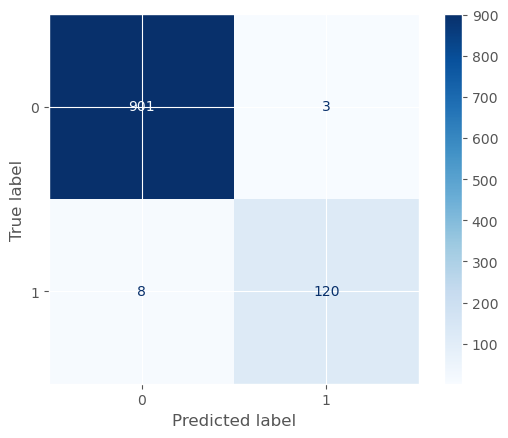

In [166]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.show()

True Negatives (Góc trên bên trái): Số lượng tin nhắn bình thường (ham) được dự đoán đúng là ham.

False Positives (Góc trên bên phải): Số lượng tin nhắn bình thường nhưng bị dự đoán nhầm thành spam (báo nhầm - lỗi quan trọng cần hạn chế để không làm phiền người dùng).

False Negatives (Góc dưới bên trái): Số lượng tin nhắn spam thực tế nhưng lại bị dự đoán nhầm thành ham (bỏ sót tin rác - lọt lưới vào hộp thư đến).

True Positives (Góc dưới bên phải): Số lượng tin nhắn spam được phát hiện và bắt giữ chính xác.

Ma trận nhầm lẫn (Confusion Matrix) nhằm trực quan hóa chi tiết các dự đoán của mô hình so với nhãn thực tế trên tập kiểm thử (X_test_tfidf).

In [ ]:
# Khai báo một danh sách gồm 10 câu email giả lập (có cả tin rác/quảng cáo lẫn tin nhắn giao tiếp đời thường)
emails = [
    "Congratulations! You have won a FREE vacation to Dubai.",  
    "Hey, don't forget our meeting tomorrow at 3 PM.",  
    "URGENT! Your bank account has been suspended. Verify immediately.",  
    "Can you pick up some groceries on your way home?",  
    "You have been selected to receive a $500 Amazon gift card.",  
    "Happy Birthday! Wishing you a wonderful day ahead.",  
    "Limited-time offer! Buy one, get one free. Shop today!",  
    "I'll send you the project files once I reach home.",  
    "Claim your lottery prize by clicking the link below.",  
    "Let's have lunch together this weekend."  
]

# Chuyển đổi các câu email thô thành ma trận số học TF-IDF bằng bộ từ vựng đã học (chỉ dùng .transform(), không fit lại)
emails_vectorized = tfidf.transform(emails)

# Dùng mô hình tốt nhất hiện tại (best_model) để dự đoán nhãn cho danh sách email mới (trả về mảng 0 hoặc 1)
predictions = best_model.predict(emails_vectorized)

# Vòng lặp duyệt song song qua từng email và nhãn dự đoán tương ứng để in kết quả ra màn hình
for email, predictions in zip(emails, predictions):
    # Quy đổi nhãn số sang chữ: số 1 là "Spam", số 0 là "Ham" (tin bình thường)
    label = "Spam" if predictions == 1 else "Ham"
    
    # In nội dung email gốc
    print(f"Email: {email}")
    # In nhãn dự đoán của mô hình
    print(f"Prediction: {label}")
    # In đường gạch ngang phân cách giữa các email cho dễ nhìn
    print("-" * 70)

Email: Congratulations! You have won a FREE vacation to Dubai.
Prediction: Spam
----------------------------------------------------------------------
Email: Hey, don't forget our meeting tomorrow at 3 PM.
Prediction: Ham
----------------------------------------------------------------------
Email: URGENT! Your bank account has been suspended. Verify immediately.
Prediction: Spam
----------------------------------------------------------------------
Email: Can you pick up some groceries on your way home?
Prediction: Ham
----------------------------------------------------------------------
Email: You have been selected to receive a $500 Amazon gift card.
Prediction: Spam
----------------------------------------------------------------------
Email: Happy Birthday! Wishing you a wonderful day ahead.
Prediction: Ham
----------------------------------------------------------------------
Email: Limited-time offer! Buy one, get one free. Shop today!
Prediction: Ham
--------------------------

In [168]:
import pickle

with open("spam_classifier.pkl", "wb") as file:
    pickle.dump(best_model, file)

lưu (export) mô hình máy học tốt nhất (best_model) vào một tập tin trên ổ cứng bằng thư viện pickle của Python, giúp bạn có thể tái sử dụng mô hình này sau mà không cần phải huấn luyện lại từ đầu.

In [169]:
with open("tfidf_vectorizer.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Success")

Success


In [170]:
with open("spam_classifier.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("tfidf_vectorizer.pkl", "rb") as file:
    loaded_vectorizer = pickle.load(file)

để tải (load) ngược lại mô hình phân loại (spam_classifier.pkl) và bộ trích xuất đặc trưng TfidfVectorizer (tfidf_vectorizer.pkl) từ ổ cứng lên bộ nhớ để chuẩn bị đưa vào ứng dụng thực tế (Production / Deployment).

In [171]:
email = [
    "Congratulations! You have won a FREE vacation to Dubai."
]

email_vector = loaded_vectorizer.transform(email)

predictions = loaded_model.predict(email_vector)[0]

quy trình dự đoán thực tế (Inference) trên một email đơn lẻ bằng cách sử dụng mô hình và bộ vectorizer đã được tải lên từ file (loaded_model và loaded_vectorizer).

In [172]:
print("Spam" if predictions == 1 else "Ham")

Spam
